# S04.03 — Regresión Logística
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `siniestro_alto` — 0 = sin siniestro, 1 = al menos un siniestro  
**Técnica:** Regresión logística (`LogisticRegression` de scikit-learn)  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos

---

## 1. Contexto actuarial

### 1.1 El problema

Además de predecir cuánto cobrar (prima), una aseguradora necesita saber
**quién tiene mayor probabilidad de reportar al menos un siniestro**.
Esta información sirve para:

- **Suscripción:** decidir si aceptar o rechazar una póliza.
- **Tarificación de dos partes:** estimar la frecuencia antes de estimar la severidad.
- **Retención:** identificar asegurados de alto riesgo para renegociar condiciones.

La variable `siniestro_alto` en el dataset es **binaria** (0/1), por lo que necesitamos
un modelo de **clasificación**, no de regresión continua.

### 1.2 Regla de leakage crítica

`siniestro_alto` se define como `int(n_siniestros > 0)`. Por lo tanto:

> **`n_siniestros` y `monto_siniestro` NO pueden usarse como features** —
> conocer esas variables implica que ya se sabe el resultado del siniestro.
> En producción, en el momento de suscripción esas columnas son desconocidas.

> *Fuentes:* ESL Cap. 4 §4.4; ISLP Cap. 4 §4.3; FREES Cap. 12.

## 2. Fundamento matemático

### 2.1 La función sigmoide

La regresión logística modela la **probabilidad** de que $Y=1$:

$$P(Y=1 \mid \mathbf{x}) = \sigma\!\left(\beta_0 + \mathbf{x}^\top \boldsymbol{\beta}\right),
\quad \text{donde} \quad
\sigma(z) = \frac{1}{1 + e^{-z}}$$

La función $\sigma$ garantiza que la salida esté en $(0,1)$.

### 2.2 Log-odds (logit)

Tomando el logaritmo del cociente de probabilidades:

$$\log \frac{P(Y=1)}{P(Y=0)} = \beta_0 + \mathbf{x}^\top \boldsymbol{\beta}$$

Cada coeficiente $\beta_j$ es el cambio en el **log-odds** cuando $x_j$ aumenta
en una unidad. $e^{\beta_j}$ es el **odds ratio** — fácilmente interpretable:

- $e^{\beta_j} > 1$: la variable aumenta las probabilidades de siniestro.
- $e^{\beta_j} < 1$: la variable las reduce.

### 2.3 Estimación por máxima verosimilitud

Los parámetros se estiman minimizando la **log-verosimilitud negativa**
(también llamada *cross-entropy*):

$$\mathcal{L}(\boldsymbol{\beta}) = -\sum_{i=1}^n
\left[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right]$$

scikit-learn usa optimización numérica (`lbfgs` por defecto) para resolver esto.

### 2.4 Métricas para clasificación binaria

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **Accuracy** | $(TP+TN)/n$ | Fracción de predicciones correctas |
| **Precisión** | $TP/(TP+FP)$ | De los predichos como 1, ¿cuántos son reales? |
| **Recall** | $TP/(TP+FN)$ | De los casos reales 1, ¿cuántos detectamos? |
| **F1** | $2 \cdot P \cdot R / (P+R)$ | Media armónica precisión–recall |
| **ROC-AUC** | Área bajo curva ROC | Capacidad de ranking; 0.5=azar, 1.0=perfecto |

En seguros, el **recall** (sensibilidad) y el **ROC-AUC** son más relevantes
que la accuracy cuando la clase positiva es infrecuente.

## 3. Carga del dataset

In [1]:
import sys
from pathlib import Path

_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Exploración del target

In [2]:
TARGET = "siniestro_alto"

# Distribución de la clase
vc = df[TARGET].value_counts(normalize=True) * 100
print("Distribución de siniestro_alto:")
print(f"  0 (sin siniestro): {vc.get(0, 0):.1f}%")
print(f"  1 (con siniestro): {vc.get(1, 0):.1f}%")

# Verificar la definición: siniestro_alto = int(n_siniestros > 0)
computed = (df["n_siniestros"] > 0).astype(int)
assert (computed == df[TARGET]).all(), "El target no coincide con la definición esperada"
print("\n✓ siniestro_alto == int(n_siniestros > 0) verificado")

Distribución de siniestro_alto:
  0 (sin siniestro): 71.7%
  1 (con siniestro): 28.3%

✓ siniestro_alto == int(n_siniestros > 0) verificado


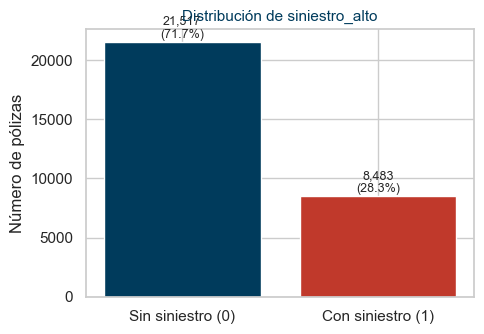

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
conteos = df[TARGET].value_counts()
colores = [NAVY, RED]
ax.bar(["Sin siniestro (0)", "Con siniestro (1)"],
       conteos.values, color=colores, edgecolor="white")
for i, v in enumerate(conteos.values):
    ax.text(i, v + 80, f"{v:,}\n({v/N*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Número de pólizas")
ax.set_title("Distribución de siniestro_alto", fontsize=11, color=NAVY)
plt.tight_layout()
plt.show()

## 5. Preparación del dataset

**Leakage A — Regla crítica:**  
`n_siniestros` y `monto_siniestro` no pueden estar en `X` cuando el target es
`siniestro_alto`. Estas columnas **son** parte de `TARGET_COLUMNS` y no están
en `FEATURE_COLUMNS`, así que la exclusión ya está garantizada por diseño.
Verificamos de todas formas.

In [4]:
X_raw = df[FEATURE_COLUMNS]
y     = df[TARGET]

# Verificaciones de leakage
for t in TARGET_COLUMNS:
    assert t not in X_raw.columns, f"Leakage: {t} en X"
assert "id_poliza_sin" not in X_raw.columns
print("✓ Sin leakage de targets ni id_poliza_sin")

# OHE de categóricas
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Proporción clase 1 en train: {y_train.mean():.3f}")
print(f"Proporción clase 1 en test:  {y_test.mean():.3f}  (stratify=y garantiza balance)")

✓ Sin leakage de targets ni id_poliza_sin
Features tras OHE: 37 columnas

Train: 24,000 | Test: 6,000
Proporción clase 1 en train: 0.283
Proporción clase 1 en test:  0.283  (stratify=y garantiza balance)


## 6. Entrenamiento del modelo

La regresión logística en scikit-learn incluye regularización L2 por defecto
(`C=1.0`). Usamos `StandardScaler` en el pipeline para que las features
numéricas tengan el mismo orden de magnitud y la regularización sea equitativa.

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logit",  LogisticRegression(
        C=1.0,
        max_iter=500,
        solver="lbfgs",
        random_state=SEED,
    )),
]) #solver es el metodo numerico p

pipeline.fit(X_train, y_train)
print("Modelo entrenado.")
# MAE y R2 no se utilizan porque es con base en residuos.
# Aquí es ver, que tanto de lo que ese esta prediciendo es real
y_pred        = pipeline.predict(X_test)
y_pred_proba  = pipeline.predict_proba(X_test)[:, 1]  # probabilidad de clase 1

acc   = accuracy_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_pred_proba)
print(f"\nAccuracy (test):  {acc:.4f}")
print(f"ROC-AUC (test):   {auc:.4f}")
print()
print("Reporte de clasificación (test):")
print(classification_report(y_test, y_pred,
                             target_names=["Sin siniestro (0)", "Con siniestro (1)"]))

Modelo entrenado.

Accuracy (test):  0.7285
ROC-AUC (test):   0.6895

Reporte de clasificación (test):
                   precision    recall  f1-score   support

Sin siniestro (0)       0.75      0.93      0.83      4303
Con siniestro (1)       0.55      0.22      0.31      1697

         accuracy                           0.73      6000
        macro avg       0.65      0.57      0.57      6000
     weighted avg       0.69      0.73      0.68      6000



## 7. Curva ROC y AUC

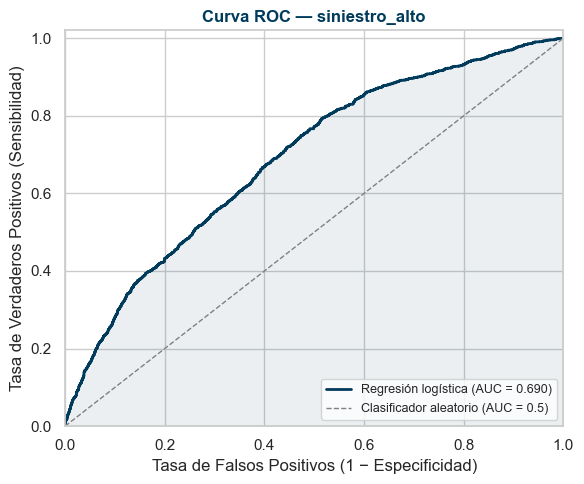

AUC = 0.6895
Interpretación: el modelo ordena correctamente las primas de riesgo en 69.0% de los pares aleatorios de pólizas 0/1.


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=NAVY, linewidth=2.0,
        label=f"Regresión logística (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linewidth=1.0,
        linestyle="--", label="Clasificador aleatorio (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.08, color=NAVY)
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curva ROC — siniestro_alto",
             fontsize=12, fontweight="bold", color=NAVY)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print(f"AUC = {auc:.4f}")
print("Interpretación: el modelo ordena correctamente las primas de riesgo en",
      f"{auc*100:.1f}% de los pares aleatorios de pólizas 0/1.")

## 8. Matriz de confusión

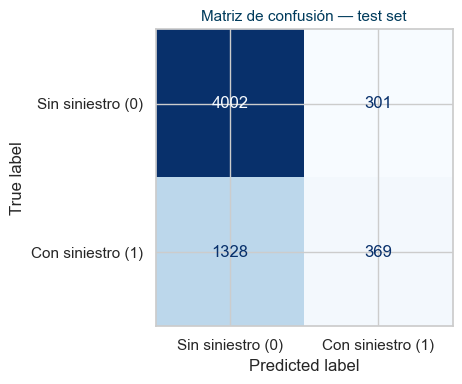

VP (True Positives):  369  — siniestros correctamente detectados
VN (True Negatives):  4,002  — no-siniestros correctamente descartados
FP (False Positives): 301  — no-siniestros erróneamente clasificados como siniestros
FN (False Negatives): 1,328  — siniestros no detectados (error más costoso en seguros)


In [9]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sin siniestro (0)", "Con siniestro (1)"],
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusión — test set",
             fontsize=11, color=NAVY)
plt.tight_layout()
plt.show()

print(f"VP (True Positives):  {tp:,}  — siniestros correctamente detectados")
print(f"VN (True Negatives):  {tn:,}  — no-siniestros correctamente descartados")
print(f"FP (False Positives): {fp:,}  — no-siniestros erróneamente clasificados como siniestros")
print(f"FN (False Negatives): {fn:,}  — siniestros no detectados (error más costoso en seguros)")

## 9. Coeficientes e interpretación mediante odds ratios

In [10]:
logit_model = pipeline.named_steps["logit"]
scaler      = pipeline.named_steps["scaler"]

coef_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coeficiente": logit_model.coef_[0],
    "Odds Ratio":  np.exp(logit_model.coef_[0]),
}).sort_values("Coeficiente", key=abs, ascending=False)

print(f"Intercepto β₀ = {logit_model.intercept_[0]:+.4f}")
print()
print("Top 12 coeficientes (features estandarizadas):")
print(coef_df.head(12).to_string(index=False, float_format="{:.4f}".format))

Intercepto β₀ = -1.0422

Top 12 coeficientes (features estandarizadas):
                    Feature  Coeficiente  Odds Ratio
 nivel_riesgo_asignado_Alto       0.6994      2.0125
nivel_riesgo_asignado_Medio       0.4394      1.5517
        antiguedad_vehiculo       0.1396      1.1498
    tipo_vehiculo_Deportivo       0.1258      1.1340
       tipo_vehiculo_Pickup       0.0826      1.0861
     tipo_vehiculo_Compacto      -0.0448      0.9562
          tipo_vehiculo_SUV       0.0424      1.0433
           num_renovaciones      -0.0322      0.9683
    estado_civil_divorciado       0.0213      1.0215
                kilometraje       0.0207      1.0209
       uso_vehiculo_Trabajo       0.0180      1.0181
         forma_pago_Mensual       0.0168      1.0169


In [ ]:
# Gráfico de odds ratios — top 12
top12 = coef_df.head(12).copy()
colores = [RED if c > 0 else NAVY for c in top12["Coeficiente"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top12["Feature"], top12["Odds Ratio"], color=colores, edgecolor="white")
ax.axvline(1.0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds Ratio ($e^{\\beta}$)")
ax.set_title("Odds Ratios — Regresión Logística (siniestro_alto)\n"
             "(OR > 1: aumenta riesgo; OR < 1: reduce riesgo)",
             fontsize=11, color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Análisis de probabilidades predichas

In [ ]:
# Distribución de probabilidades predichas, separada por clase real
df_test_prob = pd.DataFrame({
    "prob_siniestro": y_pred_proba,
    "clase_real":     y_test.values,
})

fig, ax = plt.subplots(figsize=(8, 4))
for clase, color, etiqueta in [(0, NAVY, "Sin siniestro (0)"), (1, RED, "Con siniestro (1)")]:
    sub = df_test_prob[df_test_prob["clase_real"] == clase]["prob_siniestro"]
    ax.hist(sub, bins=40, alpha=0.55, color=color, density=True, label=etiqueta)

ax.axvline(0.5, color="gray", linewidth=1.0, linestyle="--", label="Umbral 0.5")
ax.set_xlabel("Probabilidad predicha de siniestro")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de probabilidades predichas por clase real",
             fontsize=11, color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Probabilidad media predicha para clase 0:",
      f"{df_test_prob[df_test_prob['clase_real']==0]['prob_siniestro'].mean():.3f}")
print("Probabilidad media predicha para clase 1:",
      f"{df_test_prob[df_test_prob['clase_real']==1]['prob_siniestro'].mean():.3f}")

## 11. Análisis de umbral de clasificación

El umbral predeterminado es 0.5, pero en seguros puede convenir ajustarlo.
Si el costo de un **falso negativo** (perder un siniestro) es mayor que el
de un **falso positivo** (cobrar de más a un asegurado seguro), se puede
bajar el umbral para aumentar el recall.

In [11]:
umbrales = np.arange(0.20, 0.81, 0.05)
rows_umbral = []

for u in umbrales:
    y_pred_u = (y_pred_proba >= u).astype(int)
    cm_u     = confusion_matrix(y_test, y_pred_u)
    tn_u, fp_u, fn_u, tp_u = cm_u.ravel()
    prec_u   = tp_u / (tp_u + fp_u) if (tp_u + fp_u) > 0 else 0
    rec_u    = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0
    rows_umbral.append({
        "Umbral":     f"{u:.2f}",
        "Precisión":  f"{prec_u:.3f}",
        "Recall":     f"{rec_u:.3f}",
        "FN":         fn_u,
        "FP":         fp_u,
    })

umbral_df = pd.DataFrame(rows_umbral)
print("Métricas por umbral de clasificación:")
print(umbral_df.to_string(index=False))

Métricas por umbral de clasificación:
Umbral Precisión Recall   FN   FP
  0.20     0.360  0.856  244 2588
  0.25     0.377  0.794  349 2228
  0.30     0.423  0.535  789 1241
  0.35     0.486  0.397 1023  712
  0.40     0.508  0.367 1074  603
  0.45     0.521  0.310 1171  483
  0.50     0.551  0.217 1328  301
  0.55     0.579  0.131 1474  162
  0.60     0.647  0.039 1631   36
  0.65     0.667  0.005 1689    4
  0.70     0.000  0.000 1697    0
  0.75     0.000  0.000 1697    0
  0.80     0.000  0.000 1697    0


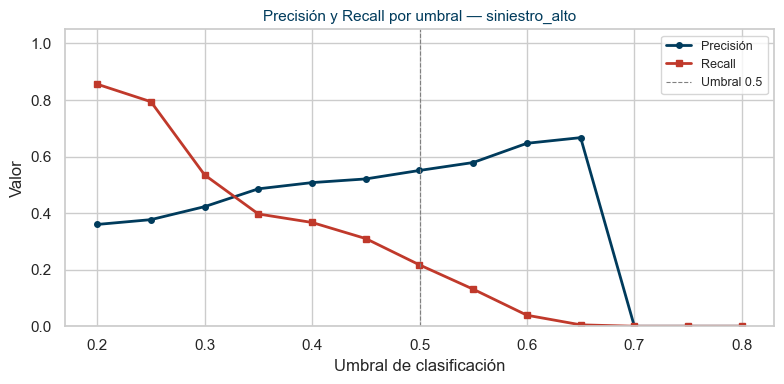

In [12]:
# Gráfico Precisión vs Recall por umbral
precs = [float(r["Precisión"]) for _, r in umbral_df.iterrows()]
recs  = [float(r["Recall"])    for _, r in umbral_df.iterrows()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(umbrales, precs, color=NAVY, linewidth=2.0, marker="o", markersize=4, label="Precisión")
ax.plot(umbrales, recs,  color=RED,  linewidth=2.0, marker="s", markersize=4, label="Recall")
ax.axvline(0.5, color="gray", linewidth=0.8, linestyle="--", label="Umbral 0.5")
ax.set_xlabel("Umbral de clasificación")
ax.set_ylabel("Valor")
ax.set_title("Precisión y Recall por umbral — siniestro_alto",
             fontsize=11, color=NAVY)
ax.legend(fontsize=9)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## 12. Conclusiones actuariales

| Métrica | Valor | Interpretación actuarial |
|---------|-------|-------------------------|
| ROC-AUC | (ver arriba) | Capacidad de ranking: ¿ordena bien riesgos? |
| Recall (0.5) | — | Fracción de siniestros correctamente detectados |
| FN (0.5) | — | Siniestros perdidos (riesgo financiero para la aseguradora) |

**El ROC-AUC es la métrica principal** para este contexto porque:

1. Mide la capacidad del modelo para **ordenar** pólizas de mayor a menor riesgo,
   que es lo que necesita suscripción (no la clasificación dura 0/1).
2. Es independiente del umbral elegido (a diferencia de accuracy y F1).
3. Es equivalente a la **concordancia de Somer's D** en estadística actuarial.

**Limitaciones del modelo logístico en seguros:**

- Supone que el log-odds es lineal en las features. Esto puede ser restrictivo
  si las relaciones son no lineales (ver S04.04 para árboles de decisión).
- El dataset sintético tiene una tasa de siniestros moderada; en datos reales
  la clase positiva suele ser mucho más pequeña, lo que requiere técnicas
  de manejo de desbalance (SMOTE, pesos de clase, etc.).
- La separación perfecta puede causar que los coeficientes diverjan; se
  recomienda siempre verificar la convergencia con `max_iter` suficiente.

> *S04.04 (árbol de decisión) es el siguiente modelo en la currícula, capturando
> interacciones no lineales sin necesidad de especificarlas manualmente.*

## 13. Ejercicio propuesto

1. **Umbral óptimo:** si la aseguradora pierde en promedio 15,000 MXN por cada
   siniestro no detectado (FN) y pierde 500 MXN por cada FP (costos operativos),
   ¿cuál es el umbral que minimiza el costo total esperado en el conjunto de test?
   *Pista:* usa la tabla de métricas por umbral de la sección 11.

2. **Regularización:** cambia `C` a 0.1 y a 10.0. ¿Cómo cambia el ROC-AUC?
   ¿Qué valor de `C` produce coeficientes con mayor magnitud?

3. **Comparación con baseline:** ajusta un modelo que siempre predice la clase
   mayoritaria. ¿Qué accuracy y ROC-AUC obtiene? ¿Por qué la accuracy no
   es suficiente para evaluar este problema?

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Cap. 4 §4.4.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 4 §4.3–4.5.
- Frees, E. W. (2009). *Regression Modeling with Actuarial and Financial Applications*. Cambridge. Cap. 12.
- scikit-learn Developers. *User Guide* v1.9.0. `LogisticRegression`, `roc_auc_score`, `ConfusionMatrixDisplay`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 3 (GLM y modelos de frecuencia).
